# Ostheoporosis Risk Prediction Models

For predicting the risk of osteoporosis, I will be using the following models:

* Logistic Regression
* Random Forest Classifier
* Decision Tree Classifier
* Support Vector Classifier

In [32]:

#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import joblib
#the warnings for multi_class is used, its was deprecated for using this
import warnings

warnings.filterwarnings(
    "ignore",
    message=".*multi_class.*deprecated.*"
)

In [34]:
#Load encoded dataset
df=pd.read_csv(r'C:\Users\shobi\Documents\GitHub\Osteoporosis-Risk-Prediction\data\osteoporosis_encoded.csv')
print(df.head(5))

   Age  Gender  Hormonal Changes  Family History  Race/Ethnicity  Body Weight  \
0   69       0                 0               1               1            1   
1   32       0                 0               1               1            1   
2   89       0                 1               0               2            0   
3   78       0                 0               0               2            1   
4   38       1                 1               1               0            0   

   Calcium Intake  Vitamin D Intake  Physical Activity  Smoking  \
0               1                 1                  1        1   
1               1                 1                  1        0   
2               0                 1                  0        0   
3               0                 0                  1        1   
4               1                 1                  0        1   

   Alcohol Consumption  Medical Conditions  Medications  Prior Fractures  \
0                    0            

### Train Test split data

In [13]:
df.columns

Index(['Age', 'Gender', 'Hormonal Changes', 'Family History', 'Race/Ethnicity',
       'Body Weight', 'Calcium Intake', 'Vitamin D Intake',
       'Physical Activity', 'Smoking', 'Alcohol Consumption',
       'Medical Conditions', 'Medications', 'Prior Fractures', 'Osteoporosis'],
      dtype='object')

In [14]:
X_train,X_test,y_train,y_test = train_test_split(df.drop('Osteoporosis',axis=1),df['Osteoporosis'],test_size=0.30,random_state=101)

### Logistic Regression

In [15]:
### Logistic Regression model import
from sklearn.linear_model import LogisticRegression

#creating logistic regression object
logmodel=LogisticRegression()

##### Hyperparameter Tuning using GridsearchCV

In [16]:
from sklearn.model_selection import GridSearchCV
#parameter for grid search

param_grid = {'C':[0.1,1,10,100,1000],
              'penalty':['l1','l2'],
              'solver':['liblinear'],
              'max_iter':[100,1000,2500,5000],
              'multi_class':['auto','ovr'],
              'random_state':[0,42,101]}

#grid search object
grid = GridSearchCV(logmodel,param_grid=param_grid,refit=True,verbose=3,cv=5,n_jobs=-1)

#fitting the data
grid.fit(X_train,y_train)

#best parameters
print(grid.best_params_)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits
{'C': 0.1, 'max_iter': 100, 'multi_class': 'auto', 'penalty': 'l2', 'random_state': 0, 'solver': 'liblinear'}


In [17]:
#logistic regression with best parameter
logmodel = LogisticRegression(C= 0.1, max_iter= 100, multi_class= 'auto', penalty= 'l2', random_state= 0, solver= 'liblinear')

#fitting the data
logmodel.fit(X_train,y_train)

#training accuracy
print('Training accuracy :',logmodel.score(X_train,y_train))

#prediction
lr_prediction = logmodel.predict(X_test)

Training accuracy : 0.8284671532846716


In [18]:
# Save the trained model
joblib.dump(logmodel, r"C:\Users\shobi\Documents\GitHub\Osteoporosis-Risk-Prediction\models\logistic_regression_model.pkl")

print("Model saved successfully!")

Model saved successfully!


### Random Forest Classifier

In [19]:
from sklearn.ensemble import RandomForestClassifier

#creating random forest classifier object
rfc = RandomForestClassifier()

##### Hyperparameter Tuning using GridsearchCV

In [ ]:
#parameter for grid search
param_grid={'criterion':['gini','entropy'],
            'max_depth':[10,20,30],
            'min_samples_split':[2,5,10],
            'min_samples_leaf':[2,5,10],
            'random_state':[0,42,101]
}

#grid search object
grid = GridSearchCV(rfc,param_grid=param_grid,refit=True,cv=5,n_jobs=-1,verbose=3)

#fitting the data
grid.fit(X_train,y_train)

#best parameters
print(grid.best_params_)

In [20]:
#random forest with best parameters
rfc = RandomForestClassifier(criterion= 'gini', max_depth= 20, min_samples_leaf= 2, min_samples_split= 2, random_state = 42)

#fitting the data
rfc.fit(X_train,y_train)

#training accuracy
print('Training accuracy :',rfc.score(X_train,y_train))

#prediction
rfc_pred = rfc.predict(X_test)

Training accuracy : 0.9394160583941605


In [21]:
# Save the trained model
joblib.dump(rfc, r"C:\Users\shobi\Documents\GitHub\Osteoporosis-Risk-Prediction\models\RFC_model.pkl")

print("Model saved successfully!")

Model saved successfully!


### Decision Tree Classifier

In [22]:
from sklearn.tree import DecisionTreeClassifier

#create decision tree classifier object
dtree = DecisionTreeClassifier()

##### Hyperparameter Tuning using GridsearchCV

In [23]:
#parameter for grid search
param_grid = {'criterion':['gini','entropy'],
              'max_depth':[10,20,30],
              'min_samples_split':[2,5,10],
              'min_samples_leaf':[2,5,10],
              'random_state':[0,42,101]}

#grid search object
grid = GridSearchCV(dtree,param_grid=param_grid,refit=True,cv=5,n_jobs=-1,verbose=3)

#fitting the gird
grid.fit(X_train,y_train)

#best parameters
print(grid.best_params_)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 2, 'random_state': 0}


In [24]:
#decision tree classifier with best parameter
dtree = DecisionTreeClassifier(criterion= 'entropy', max_depth= 10, min_samples_leaf= 10, min_samples_split= 2, random_state= 0)

#fitting the data
dtree.fit(X_train,y_train)

#training accuracy
print('Training accuracy :',dtree.score(X_train,y_train))

#prediction
dtree_pred = dtree.predict(X_test)

Training accuracy : 0.9094890510948905


In [25]:
# Save the trained model
joblib.dump(dtree, r"C:\Users\shobi\Documents\GitHub\Osteoporosis-Risk-Prediction\models\DFC_model.pkl")

print("Model saved successfully!")

Model saved successfully!


### Support Vector Classifier

In [26]:
from sklearn.svm import SVC

# Create SVC with linear kernel
svc = SVC()

##### Hyperparameter Tuning using GridsearchCV

In [27]:
#parameters for grid search
param_grid = {'C':[0.1,1,10,100,1000],
              'degree':[2,3,4,5],
              'gamma':['scale','auto'],
              'random_state':[0,42,101]}

#grid search object
grid = GridSearchCV(estimator=svc,param_grid=param_grid,refit=True,cv=5,n_jobs=-1,verbose=3)

#fitting the data
grid.fit(X_train,y_train)

#best parameter
print(grid.best_params_)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
{'C': 1, 'degree': 2, 'gamma': 'auto', 'random_state': 0}


In [28]:
#support vector classifier with best parameters
svc= SVC( kernel='linear',C= 1, degree= 2, gamma= 'auto', random_state= 0)

#fitting the data
svc.fit(X_train,y_train)

#training accuracy
print('Training accuracy :',svc.score(X_train,y_train))

svc_predit = svc.predict(X_test)

Training accuracy : 0.8343065693430657


In [29]:
# Save the trained model
joblib.dump(svc, r"C:\Users\shobi\Documents\GitHub\Osteoporosis-Risk-Prediction\models\SVC_model.pkl")

print("Model saved successfully!")

Model saved successfully!


### Model Evaluation

#### Confusion Matrix

Text(0.5, 1.0, 'Support Vector Classifier')

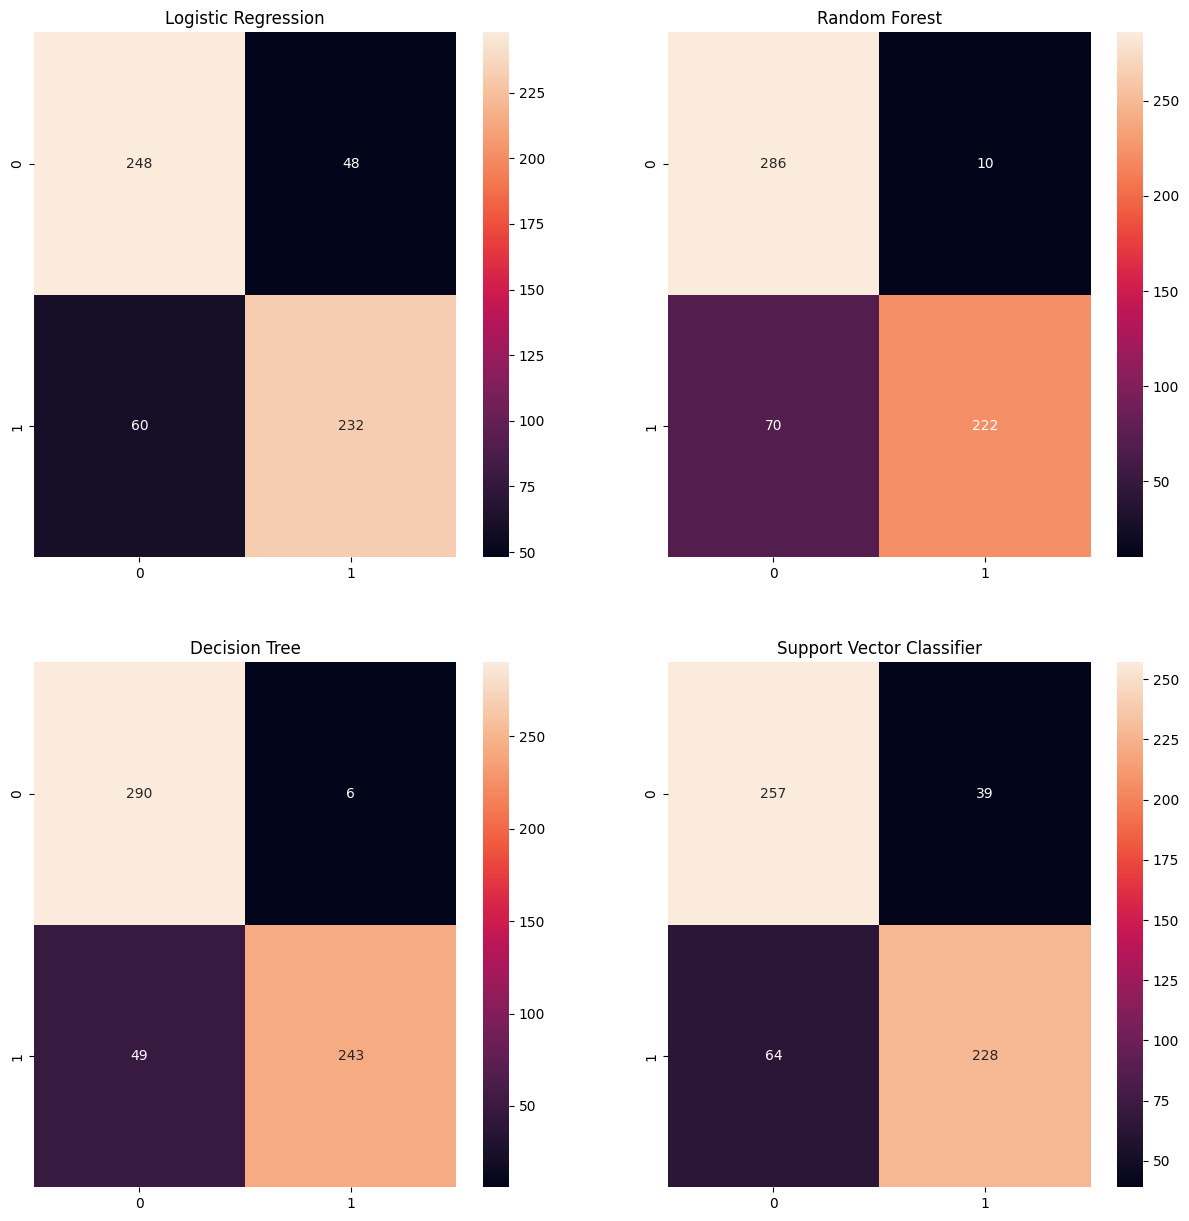

In [30]:
from sklearn.metrics import confusion_matrix
fig,ax = plt.subplots(2,2,figsize=(15,15))

#confusion matrix for logistic regression
cm = confusion_matrix(y_test,lr_prediction)
sns.heatmap(cm,annot=True,fmt="g",ax=ax[0,0]).set_title('Logistic Regression')

#confusion matrix for random forest classifier
cm = confusion_matrix(y_test,rfc_pred)
sns.heatmap(cm,annot=True,fmt="g",ax=ax[0,1]).set_title('Random Forest')

#confusion matrix for decision tree classifier
cm = confusion_matrix(y_test,dtree_pred)
sns.heatmap(cm,annot=True,fmt="g",ax=ax[1,0]).set_title('Decision Tree')

#confusion matrix for support vector classifier
cm=confusion_matrix(y_test,svc_predit)
sns.heatmap(cm,annot=True,fmt="g",ax=ax[1,1]).set_title('Support Vector Classifier')


#### Model Accuracy

Text(0.5, 1.0, 'Model Accuracy')

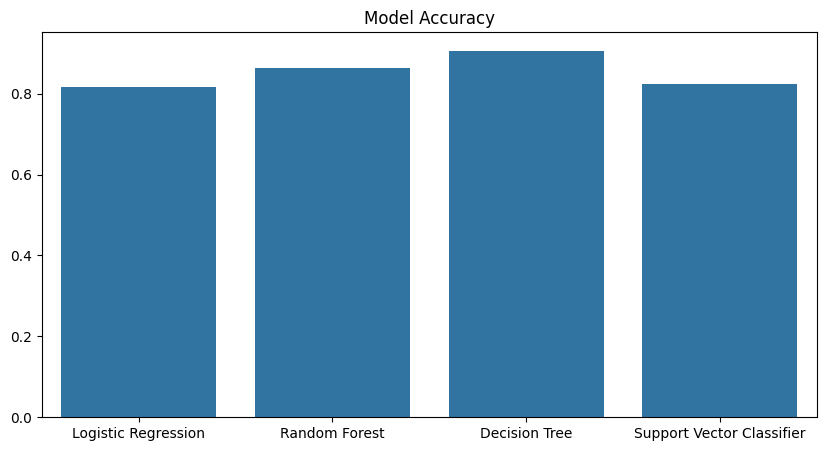

In [31]:
#Bar chart for the accuracy of the models
from sklearn.metrics import accuracy_score
models=['Logistic Regression','Random Forest','Decision Tree','Support Vector Classifier']
accuracy = [accuracy_score(y_test,lr_prediction),accuracy_score(y_test,rfc_pred),accuracy_score(y_test,dtree_pred),accuracy_score(y_test,svc_predit)]
plt.figure(figsize=(10,5))
sns.barplot(x=models,y=accuracy).set_title('Model Accuracy')

#### Model Metrics

Text(0.5, 1.0, 'R2 Score')

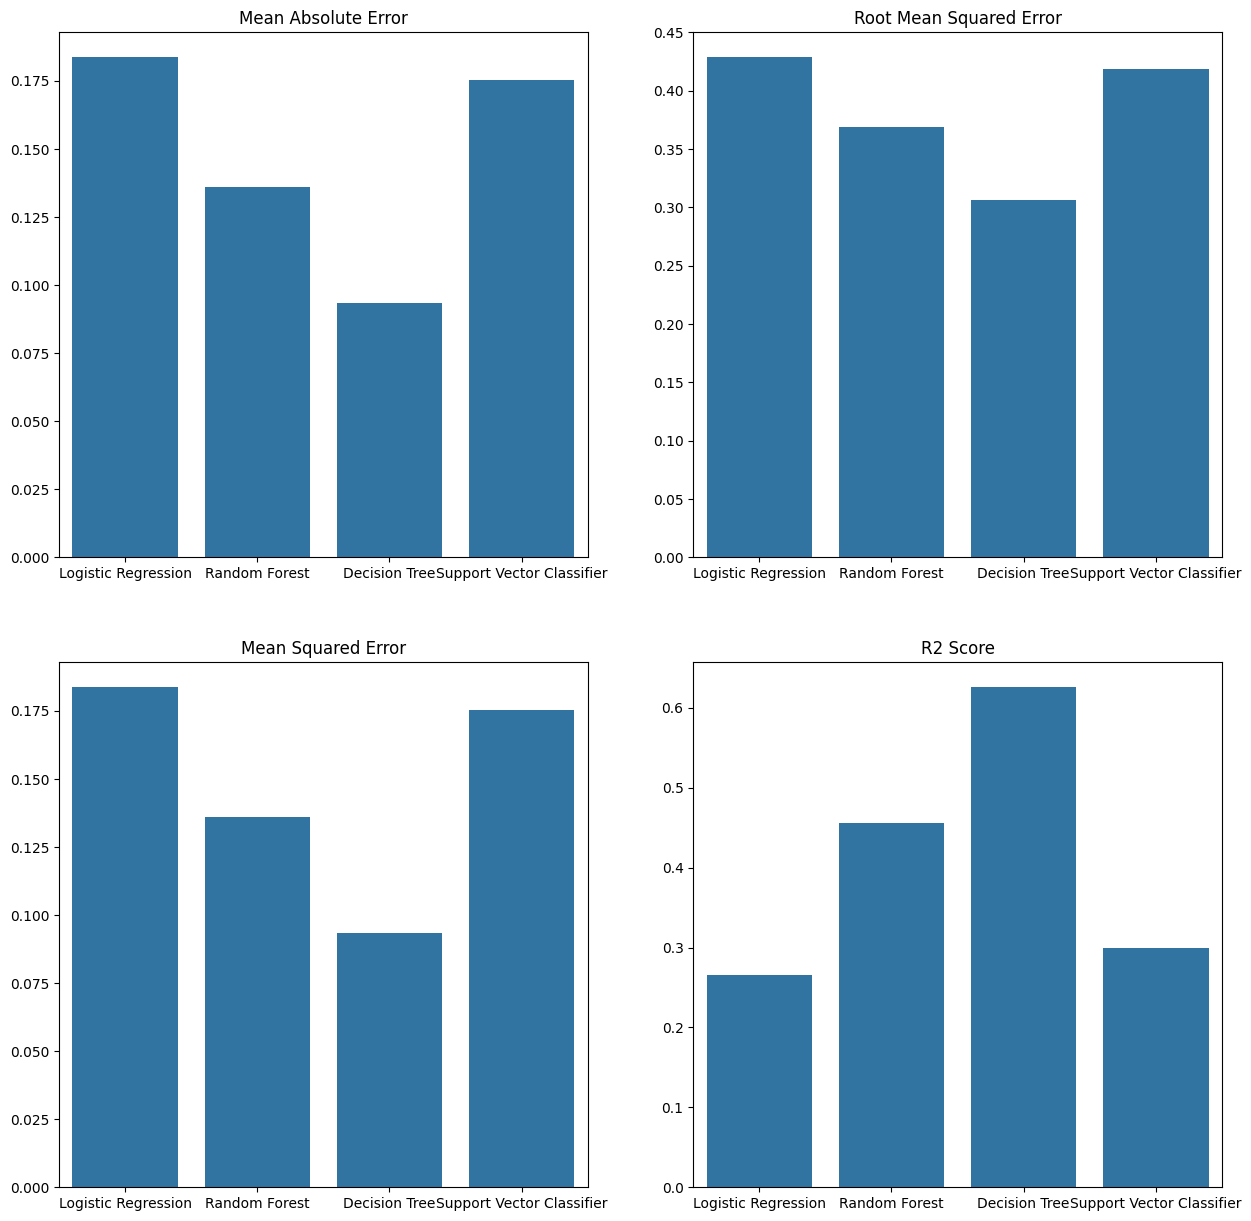

In [33]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score,root_mean_squared_error

fix,ax = plt.subplots(2,2,figsize=(15,15))
models=['Logistic Regression','Random Forest','Decision Tree','Support Vector Classifier']
mae = [mean_absolute_error(y_test,lr_prediction),mean_absolute_error(y_test,rfc_pred),mean_absolute_error(y_test,dtree_pred),mean_absolute_error(y_test,svc_predit)]
mse = [mean_squared_error(y_test,lr_prediction),mean_squared_error(y_test,rfc_pred),mean_squared_error(y_test,dtree_pred),mean_squared_error(y_test,svc_predit)]
rmse = [root_mean_squared_error(y_test,lr_prediction),root_mean_squared_error(y_test,rfc_pred),root_mean_squared_error(y_test,dtree_pred),root_mean_squared_error(y_test,svc_predit)]
r2=[r2_score(y_test,lr_prediction),r2_score(y_test,rfc_pred),r2_score(y_test,dtree_pred),r2_score(y_test,svc_predit)]

#Mean absoulte error
sns.barplot(x=models,y=mae,ax=ax[0,0]).set_title('Mean Absolute Error')

#Mean squard error
sns.barplot(x=models,y=mse,ax=ax[1,0]).set_title('Mean Squared Error')

#root mean squared error
sns.barplot(x=models,y=rmse,ax=ax[0,1]).set_title('Root Mean Squared Error')

#R2 score
sns.barplot(x=models,y=r2,ax=ax[1,1]).set_title('R2 Score')


#### Model Accuracy

Text(0.5, 1.0, 'Feature Importance for Support Vector Classifier')

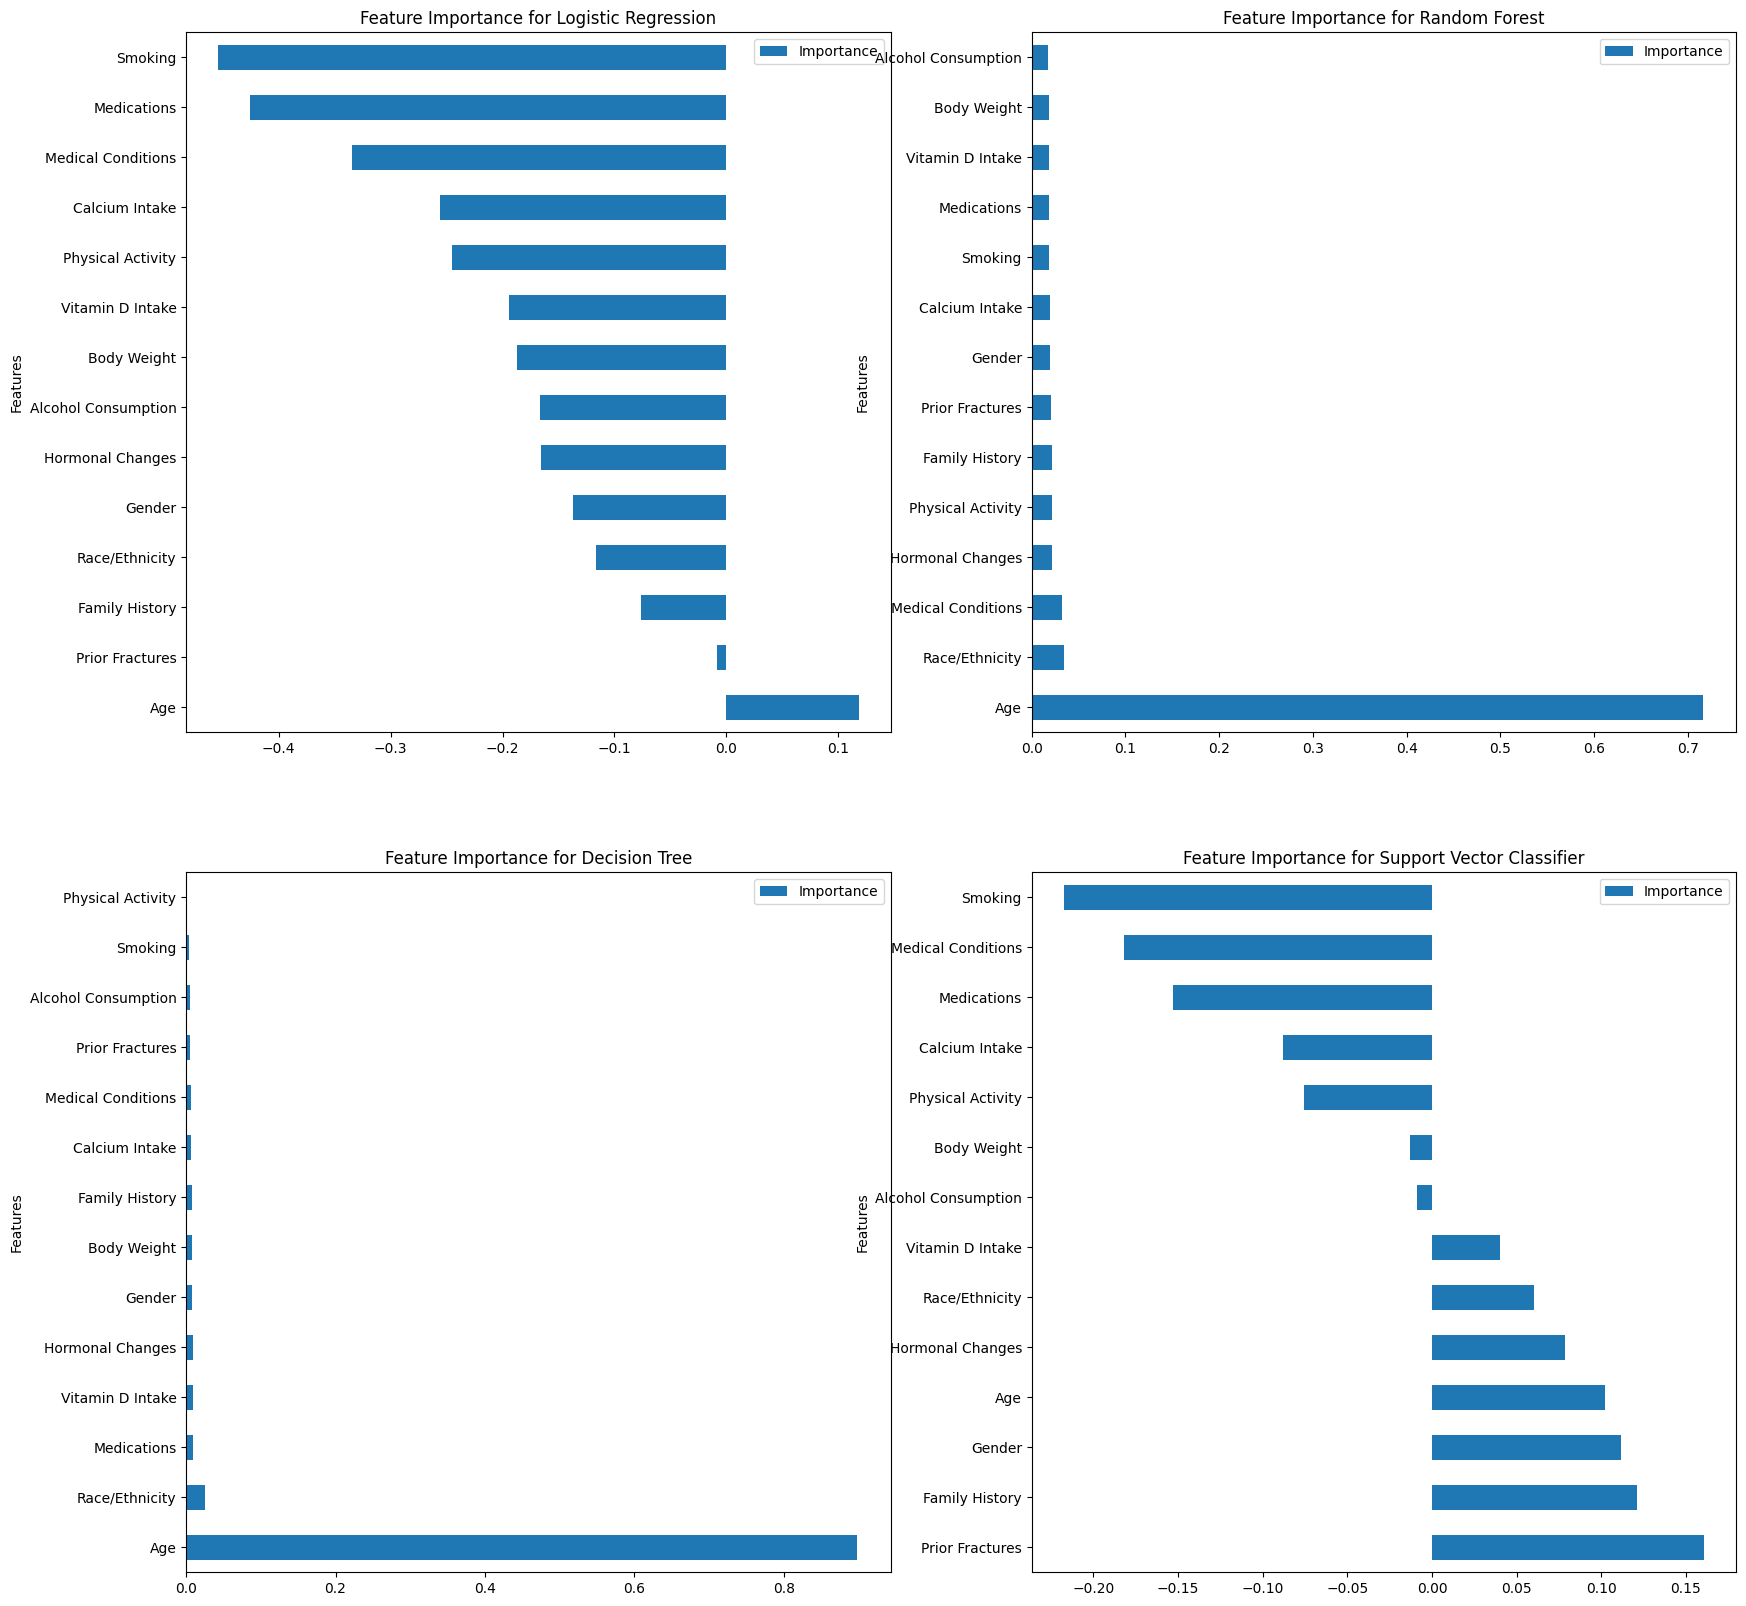

In [36]:
fig,ax = plt.subplots(2,2,figsize=(20,20))

#feature Importance graph for logistic regression
coeff=list(logmodel.coef_[0])
labels=list(df.drop('Osteoporosis',axis=1).columns)
features = pd.DataFrame()
features['Features']=labels
features['Importance']=coeff
features.sort_values(by=['Importance'],ascending=False,inplace=True)
features=features.set_index('Features')
features.plot(kind='barh',ax=ax[0,0]).set_title("Feature Importance for Logistic Regression")

#feature Importance graph for random forest
coeff=list(rfc.feature_importances_)
labels=list(df.drop('Osteoporosis',axis=1).columns)
features = pd.DataFrame()
features['Features']=labels
features['Importance']=coeff
features.sort_values(by=['Importance'],ascending=False,inplace=True)
features=features.set_index('Features')
features.plot(kind='barh',ax=ax[0,1]).set_title("Feature Importance for Random Forest")

#feature Importance graph for decision tree
coeff =list(dtree.feature_importances_)
labels=list(df.drop('Osteoporosis',axis=1).columns)
features=pd.DataFrame()
features['Features']=labels
features['Importance']=coeff
features.sort_values(by=['Importance'],ascending=False,inplace=True)
features=features.set_index('Features')
features.plot(kind='barh',ax=ax[1,0]).set_title('Feature Importance for Decision Tree')

#feature Importance graph for Support Vector Classifier
coeff=list(svc.coef_[0])
labels=list(df.drop('Osteoporosis',axis=1).columns)
features=pd.DataFrame()
features['Features']=labels
features['Importance']=coeff
features.sort_values(by=['Importance'],ascending=False,inplace=True)
features=features.set_index('Features')
features.plot(kind="barh",ax=ax[1,1]).set_title('Feature Importance for Support Vector Classifier')

## Conclusion

In this project, I developed machine learning models to predict the risk of osteoporosis in patients based on their medical records. I analyzed the dataset, performed exploratory data analysis, and developed predictive models using logistic regression, random forest classifier, decision tree classifier, and support vector classifier. I evaluated the models using confusion matrix, accuracy, precision, recall, and F1 score metrics.

From the exploratory data analysis, i have found that certain factors like Age, Hormona Changes, Medical Conditions, Medications, Lifestyle and nutrition are responsible for the risk of osteoporosis. Patients between 20-40 years of age have lower risk of osteoporosis. Patients who have undergone hormonal changes, have medical conditions, consume medications, have lower body weight, calcium and vitamin D levels, and have sedentary lifestyle have higher risk of osteoporosis.

Coming to the machine learning models, I have employed Logistic Regression, Random Tree, Decision Tree and Support Vector Classifier to predict the risk of osteoporosis based on the data. Out of these models, Decision Tree Classifier model gave the best results in comparison to others, with nearly 87% accuracy. The model can be used to predict the risk of osteoporosis in patients based on their medical records, enabling early intervention and prevention strategies.